In [0]:
import pandas as pd
from pyspark.sql.types import TimestampType
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# spark = SparkSession.builder.appName("MyApp").getOrCreate()

In [0]:
catalog = "allianz_coe"
schema = "mlops_gold"

TABLES_TO_READ = [
"dim_account",
"dim_claim",
"dim_customer",
"dim_person",
"dim_policy",
"dim_override",
"fact_complaint",
"dim_marketing",
"fact_policy",
"fact_quote"]

def cast_timestamps_to_string(df):
    for field in df.schema.fields:
        if isinstance(field.dataType, TimestampType):
            df = df.withColumn(field.name, col(field.name).cast("string"))
    return df

def load_tables_to_pandas(catalog, schema, tables):
    dataframes = {}

    for table in tables:
        df_spark = spark.table(f"{catalog}.{schema}.{table}")
        df_spark = cast_timestamps_to_string(df_spark)
        dataframes[table] = df_spark.toPandas()

    return dataframes

In [0]:
print(spark)

In [0]:
# Load all tables
dfs = load_tables_to_pandas(catalog, schema, TABLES_TO_READ)

# Access tables
dim_account = dfs["dim_account"]
dim_claim = dfs["dim_claim"]
dim_customer = dfs["dim_customer"]
dim_person = dfs["dim_person"]
dim_policy = dfs["dim_policy"]
dim_marketing = dfs["dim_marketing"]
dim_override = dfs["dim_override"]
fact_complaint = dfs["fact_complaint"]
fact_policy = dfs["fact_policy"]
fact_quote = dfs["fact_quote"]
dim_customer.head()

,customer_sk,customer_id,customer_number,customer_rating,customer_segment,line_of_business,net_promoter_score,customer_since_date,customer_status_code,customer_status_reason,income_band,customer_satisfaction,customer_age_band,net_promotor_code_segment,customer_onboarding_satisfaction_score,customer_onboarding_feedback,effective_from_ts,effective_to_ts,record_version,created_by,created_ts,last_updated_by,last_updated_ts,attr_hash
0,14870,CUS_20260615_181205_42_014870,686627,4,STANDARD,HOME,10.0,2023-11-17,ACTIVE,CUSTOMER_REQUEST,Medium,VERY_SATISFIED,26-40,PROMOTERS,5,POSITIVE,2025-06-26 18:12:05,2025-07-21 18:27:31,1,ETL_SYSTEM,2026-06-16 03:15:51.309566,ETL_SYSTEM,2026-06-16 04:26:10.620676,cd64056fb1d7bfa8c776557a3abd4f1e8d057d1e6c7fbbf8f8682d9c6c45901d
1,10667,CUS_20260615_181205_42_010667,686627,4,STANDARD,HOME,9.0,2023-03-08,ACTIVE,CUSTOMER_REQUEST,Low,SATISFIED,61-80,PROMOTERS,5,POSITIVE,2025-06-26 18:12:05,9999-12-31 00:00:00,1,ETL_SYSTEM,2026-06-16 03:15:51.309566,ETL_SYSTEM,2026-06-16 03:15:51.309566,e115befda84239090b354cae59256820f431808f2072303155e21bcfb75f8fda
2,20533,CUS_20260615_181205_42_020533,599583,4,STANDARD,MOTOR,8.0,2021-11-02,ACTIVE,CUSTOMER_REQUEST,Medium,SATISFIED,26-40,PASSIVE,4,POSITIVE,2025-06-26 18:12:05,2025-07-21 18:27:31,1,ETL_SYSTEM,2026-06-16 03:15:51.309566,ETL_SYSTEM,2026-06-16 04:26:10.620676,6502f3df5deea2d4349a4cd57b1ec8d02fe882cce58bd4adcb209deb2bcd3d32
3,4530,CUS_20260615_181205_42_004530,599583,4,STANDARD,MOTOR,5.0,2020-10-10,LAPSED,PAYMENT,Low,SATISFIED,26-40,DETRACTORS,4,POSITIVE,2025-06-26 18:12:05,9999-12-31 00:00:00,1,ETL_SYSTEM,2026-06-16 03:15:51.309566,ETL_SYSTEM,2026-06-16 03:15:51.309566,259c7e91f3cd0916349cdbee6575dd00b451995406c85bf90e2a1a857a1e6a3a
4,24352,CUS_20260615_181205_42_024352,729386,5,PREMIUM,HOME,8.0,2020-01-01,ACTIVE,CUSTOMER_REQUEST,Medium,NEUTRAL,80+,PASSIVE,4,POSITIVE,2025-06-26 18:12:05,9999-12-31 00:00:00,1,ETL_SYSTEM,2026-06-16 03:15:51.309566,ETL_SYSTEM,2026-06-16 03:15:51.309566,2bf14bfe9f0c2f580963e4603d9072fc85f95ddff87e65d47079bedbc1321dd4


## Master Data

In [0]:
master_df = fact_policy[['customer_sk', 'policy_sk', 'claim_sk', 'person_sk', 'account_sk','channel_sk', 'marketing_sk','date_sk', 'override_sk','person_id',  'policy_renewal_current_period_amt',
                         'policy_renewal_next_period_amt']].drop_duplicates().copy()
print(master_df.shape)
master_df = master_df.merge(dim_customer[['customer_sk', 'net_promoter_score', 'net_promotor_code_segment', 'customer_satisfaction']], on='customer_sk', how='left')
master_df = master_df.merge(dim_policy[['policy_sk', 'policy_start_ts', 'policy_issue_date', 'policy_sales_channel', 
                                        'policy_status', 'is_policy_renewal', 'policy_cycle']], on='policy_sk', how='left')
master_df = master_df.merge(dim_claim[['claim_sk', 'claim_id','claim_status','claim_channel', 'is_litigation',  'claim_reported_date' , 'claim_satisfaction_score'
                                       , 'claim_settlement_date']], on='claim_sk', how='left')
master_df = master_df.merge(dim_person[['person_sk', 'person_id', 'is_operational_paperless_consent']], on=['person_sk', 'person_id'], how='left')
master_df = master_df.merge(dim_account[['account_sk', 'account_id', 'account_creation_type', 'account_last_access_ts']], on='account_sk', how='left')
master_df = master_df.merge(dim_override[['override_sk', 'override_reason']], on='override_sk', how='left')
master_df = master_df.merge(dim_marketing[['marketing_sk', 'customer_service_call_frequency']], on='marketing_sk', how='left')
print(master_df.shape)

master_df = master_df.merge(fact_quote[['customer_sk','person_sk', 'account_sk', 'channel_sk','quote_id', 'quote_status', 'quote_date']], 
                            on=['customer_sk','person_sk', 'account_sk', 'channel_sk'], how='left')
print(master_df.shape)

master_df = master_df.merge(fact_complaint[['customer_sk','person_sk', 'channel_sk','complaint_date', 'complaint_id', 'complaint_resolved_date', 
                                            'is_financial_ombudsman_service_referral', 'complaint_status', 'complaint_upheld_status']], 
                            on=['customer_sk','person_sk', 'channel_sk'], how='left')

print(master_df.shape)
master_df.head()

(42567, 12)
(42567, 34)
(61769, 37)
(62100, 43)


,customer_sk,policy_sk,claim_sk,person_sk,account_sk,channel_sk,marketing_sk,date_sk,override_sk,person_id,policy_renewal_current_period_amt,policy_renewal_next_period_amt,net_promoter_score,net_promotor_code_segment,customer_satisfaction,policy_start_ts,policy_issue_date,policy_sales_channel,policy_status,is_policy_renewal,policy_cycle,claim_id,claim_status,claim_channel,is_litigation,claim_reported_date,claim_satisfaction_score,claim_settlement_date,is_operational_paperless_consent,account_id,account_creation_type,account_last_access_ts,override_reason,customer_service_call_frequency,quote_id,quote_status,quote_date,complaint_date,complaint_id,complaint_resolved_date,is_financial_ombudsman_service_referral,complaint_status,complaint_upheld_status
0,25138,4,-1,64928,25138,2,12,20211103,-1,PER_20260615_181205_42_064420,1396.8400,1615.9900,8.0,PASSIVE,NEUTRAL,2021-11-06 15:11:43,2021-11-03,AGENT,ACTIVE,Y,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_025138,ONLINE,2025-05-30 00:00:00,NaN,1.0,QUO_20260615_181205_42_000017,ACCEPTED,2024-06-29,2024-09-22,CMP00325_0000715,2024-09-28,N,Closed,Not Upheld
1,5320,9,-1,63552,5320,1,16,20250423,-1,PER_20260615_181205_42_065035,364.9500,401.3100,0.0,DETRACTORS,NEUTRAL,2025-04-24 08:31:01,2025-04-23,ONLINE,ACTIVE,Y,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005320,BRANCH,2025-02-02 00:00:00,NaN,1.0,QUO_20260615_181205_42_000023,ACCEPTED,2022-06-07,NaN,NaN,NaN,NaN,NaN,NaN
2,20757,34,-1,140121,20757,2,48,20210806,-1,PER_20260615_181205_42_144179,1670.3600,1711.5500,8.0,PASSIVE,SATISFIED,2021-08-06 22:08:19,2021-08-06,AGENT,LAPSED,N,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_020757,ONLINE,2025-05-31 00:00:00,NaN,3.0,QUO_20260615_181205_42_000062,ACCEPTED,2024-10-17,2025-11-02,CMP00334_0000724,2025-11-09,N,Closed,Upheld
3,20757,37,-1,140121,20757,1,48,20210802,-1,PER_20260615_181205_42_144179,374.6000,408.9800,8.0,PASSIVE,SATISFIED,2021-08-03 22:08:19,2021-08-02,ONLINE,ACTIVE,Y,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_020757,ONLINE,2025-05-31 00:00:00,NaN,3.0,QUO_20260615_181205_42_000063,ACCEPTED,2024-04-06,2025-05-13,CMP00335_0000725,2025-05-19,N,Closed,Partially Upheld
4,20757,37,-1,140121,20757,1,48,20210802,-1,PER_20260615_181205_42_144179,374.6000,408.9800,8.0,PASSIVE,SATISFIED,2021-08-03 22:08:19,2021-08-02,ONLINE,ACTIVE,Y,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_020757,ONLINE,2025-05-31 00:00:00,NaN,3.0,QUO_20260615_181205_42_000063,ACCEPTED,2024-04-06,2025-08-25,CMP00336_0000726,2025-08-30,N,Closed,Partially Upheld


20757

In [0]:
master_df['date_sk'].nunique()

1993

In [0]:
master_df[master_df['claim_sk']==-1].shape

(57075, 43)

In [0]:
master_df[master_df['override_sk']==-1].shape

(59953, 43)

In [0]:

def plot_channel_nps(df: pd.DataFrame):

    stats = (
        df.groupby([CHANNEL_COL, NPS_COL])
          .size()
          .reset_index(name="count")
    )

    stats["pct"] = (
        stats.groupby(CHANNEL_COL)["count"]
             .transform(lambda x: x / x.sum() * 100)
    )

    # Create pivot and ensure NPS scores 0-10 exist
    pivot = (
        stats.pivot(
            index=NPS_COL,
            columns=CHANNEL_COL,
            values="pct"
        )
        .fillna(0)
        .reindex(index=range(11), fill_value=0)      # ensure 0-10 scores
        .reindex(columns=CHANNELS, fill_value=0)     # ensure all channels exist
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    w = 0.25
    x = np.arange(len(pivot))  # always matches pivot length

    for i, ch in enumerate(CHANNELS):

        bars = ax.bar(
            x + i * w,
            pivot[ch].values,
            width=w,
            label=ch,
            color=COLORS.get(ch, "#999999"),
            alpha=0.85
        )

        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    h + 0.3,
                    f"{h:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    color="#555"
                )

    ax.axvspan(-0.4, 6.5, alpha=0.04, color="red")
    ax.axvspan(6.5, 8.5, alpha=0.04, color="yellow")
    ax.axvspan(8.5, 10.7, alpha=0.04, color="green")

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0f}%")
    )

    ax.set_xticks(x + w)
    ax.set_xticklabels(pivot.index)

    ax.set_xlabel("NPS Score (0–10)", fontsize=11)
    ax.set_ylabel(f"% of Customers within {CHANNEL_COL}", fontsize=11)
    ax.set_title(
        f"NPS Score Distribution by {CHANNEL_COL} (% within)",
        fontsize=13,
        fontweight="bold"
    )

    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

In [0]:
master_df[["net_promoter_score", "net_promotor_code_segment"]].drop_duplicates().reset_index(drop=True)

,net_promoter_score,net_promotor_code_segment
0,8.0,PASSIVE
1,0.0,DETRACTORS
2,9.0,PROMOTERS
3,10.0,PROMOTERS
4,3.0,DETRACTORS
5,7.0,PASSIVE
6,6.0,DETRACTORS
7,2.0,DETRACTORS
8,1.0,DETRACTORS
9,5.0,DETRACTORS


## NPS values

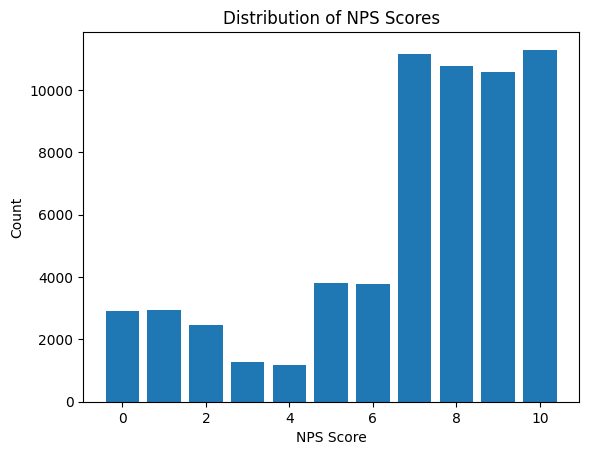

In [0]:
nps_values = master_df["net_promoter_score"].value_counts()
nps_values

plt.bar(nps_values.index, nps_values.values)
plt.xlabel("NPS Score")
plt.ylabel("Count")
plt.title("Distribution of NPS Scores")
plt.show()

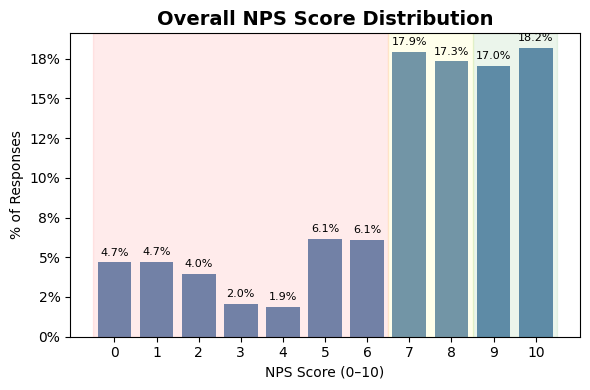

In [0]:
stats = master_df.copy()
nps_pct = (stats['net_promoter_score'].value_counts(normalize=True).sort_index().mul(100).reindex(range(11), fill_value=0))
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar( nps_pct.index, nps_pct.values, color="#4C78A8", alpha=0.85)
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text( bar.get_x() + bar.get_width()/2, h + 0.3, f"{h:.1f}%", ha="center", va="bottom", fontsize=8)
ax.axvspan(-0.5, 6.5, alpha=0.08, color="red")      # Detractors (0-6)
ax.axvspan(6.5, 8.5, alpha=0.08, color="yellow")    # Passives (7-8)
ax.axvspan(8.5, 10.5, alpha=0.08, color="green")    # Promoters (9-10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_xticks(range(11))
ax.set_xlabel("NPS Score (0–10)")
ax.set_ylabel("% of Responses")
ax.set_title("Overall NPS Score Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Onboarding Feedback

### CSAT Score

### Policy Issuance TAT

In [0]:
master_df['policy_issuance_tat'] = (pd.to_datetime(master_df['policy_start_ts']) - pd.to_datetime(master_df['policy_issue_date'])).dt.days
master_df['policy_issuance_tat'].value_counts()
pd.crosstab( master_df['policy_issuance_tat'], master_df['net_promoter_score']).round(1)

net_promoter_score,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
policy_issuance_tat,,,,,,,,,,,
0,495,468,397,216,228,880,863,2519,2430,2957,3036
1,489,464,444,220,178,909,886,2520,2344,2872,3128
2,479,426,418,207,170,910,938,2526,2517,2891,3126
3,100,116,90,29,41,165,138,591,514,293,357
4,94,150,91,46,49,162,146,582,547,300,322
5,105,118,90,70,50,97,96,680,646,344,320
6,119,122,91,45,46,143,147,559,529,195,236
7,103,102,91,48,53,82,106,620,690,331,360
8,145,152,119,47,60,71,65,73,54,53,62


In [0]:
master_df.groupby('policy_issuance_tat')['net_promoter_score'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])

,count,mean,median,std,min,max
policy_issuance_tat,,,,,,
0,14489,7.346677,8.0,2.637176,0.0,10.0
1,14454,7.340875,8.0,2.652836,0.0,10.0
2,14608,7.382119,8.0,2.600207,0.0,10.0
3,2434,6.843057,7.0,2.704523,0.0,10.0
4,2489,6.718361,7.0,2.741515,0.0,10.0
5,2616,6.878058,8.0,2.664123,0.0,10.0
6,2232,6.487455,7.0,2.776417,0.0,10.0
7,2586,7.008894,8.0,2.633426,0.0,10.0
8,901,3.946726,3.0,3.268952,0.0,10.0


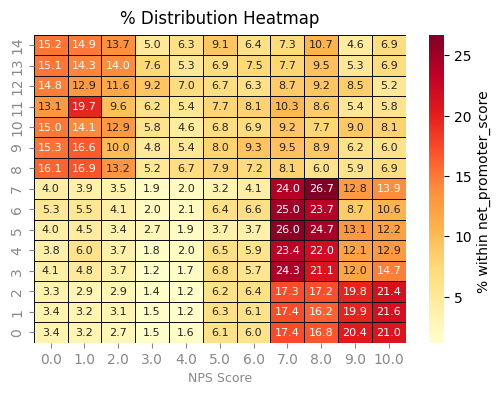

In [0]:
ct = master_df.groupby(['policy_issuance_tat', 'net_promoter_score']).size().reset_index(name="count")
ct["pct_within_channel"] = ct.groupby('policy_issuance_tat')["count"].transform(lambda x: x / x.sum() * 100).round(1)
fig, ax3 = plt.subplots(figsize=(6, 4))
pct_pivot = ct.pivot(index='net_promoter_score', columns='policy_issuance_tat', values="pct_within_channel").fillna(0).reindex(columns=master_df['policy_issuance_tat'].unique())
sns.heatmap(
    pct_pivot.T.sort_index(ascending=False),
    ax=ax3, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, linecolor="#0F1117",
    cbar_kws={f"label": "% within net_promoter_score "},
    annot_kws={"size": 8}
)
ax3.set_title("% Distribution Heatmap",fontsize=12, pad=8)
ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
ax3.set_ylabel("",          color="#888", fontsize=9)
ax3.tick_params(colors="#888")
plt.show()

### onboarding platform

In [0]:
master_df.groupby("account_creation_type")["net_promoter_score"].describe()

,count,mean,std,min,25%,50%,75%,max
account_creation_type,,,,,,,,
BRANCH,15189.0,2.579630,1.983354,0.0,1.0,2.0,5.0,6.0
ONLINE,46911.0,8.334826,1.257965,6.0,7.0,8.0,9.0,10.0


account_creation_type
ONLINE    46911
BRANCH    15189
Name: count, dtype: int64


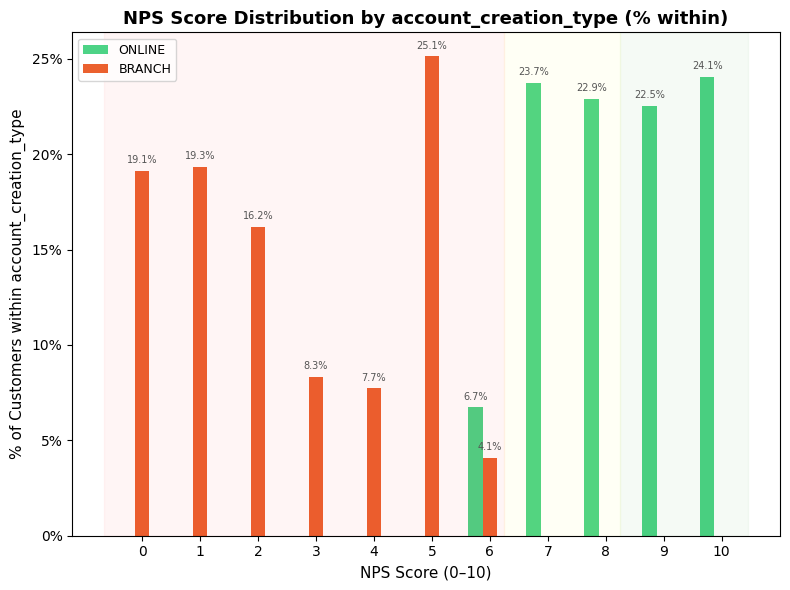

In [0]:
CHANNEL_COL = "account_creation_type"
NPS_COL     = "net_promoter_score"
CHANNELS    = ["ONLINE", "BRANCH"]
COLORS      = {"ONLINE": "#2ECC71", "BRANCH": "#E8450A"}
print(master_df[CHANNEL_COL].value_counts())
plot_channel_nps(master_df)

### Onboarding Feedback

### Drop-off During Onboarding


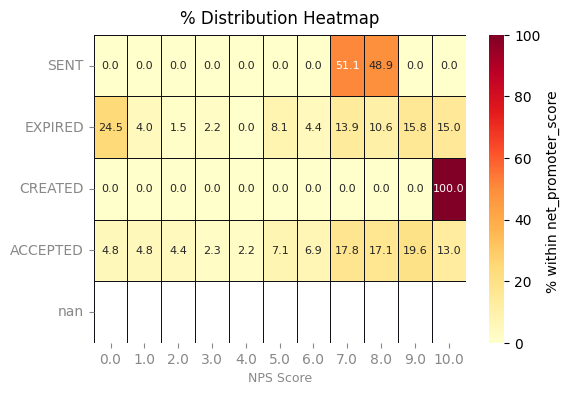

In [0]:
ct = master_df.groupby(['quote_status', 'net_promoter_score']).size().reset_index(name="count")
ct["pct_within_channel"] = ct.groupby('quote_status')["count"].transform(lambda x: x / x.sum() * 100).round(1)
fig, ax3 = plt.subplots(figsize=(6, 4))
pct_pivot = ct.pivot(index='net_promoter_score', columns='quote_status', values="pct_within_channel").fillna(0).reindex(columns=master_df['quote_status'].unique())
sns.heatmap(
    pct_pivot.T.sort_index(ascending=False),
    ax=ax3, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, linecolor="#0F1117",
    cbar_kws={f"label": "% within net_promoter_score "},
    annot_kws={"size": 8}
)
ax3.set_title("% Distribution Heatmap",fontsize=12, pad=8)
ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
ax3.set_ylabel("",          color="#888", fontsize=9)
ax3.tick_params(colors="#888")
plt.show()

quote_status
ACCEPTED    75806
CREATED      3338
SENT         2308
EXPIRED       977
Name: count, dtype: int64


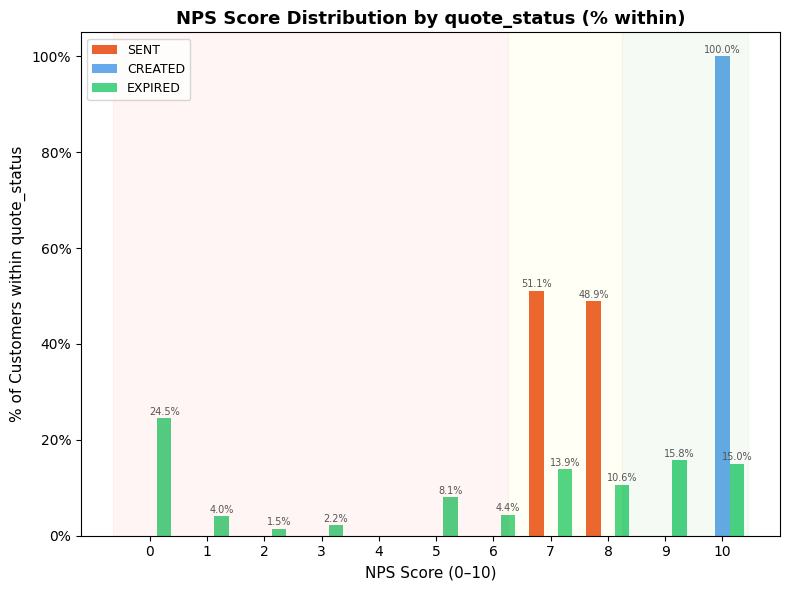

In [0]:
CHANNEL_COL = "quote_status"
NPS_COL     = "net_promoter_score"
CHANNELS    = ["SENT", "CREATED", "EXPIRED"]
COLORS      = {"SENT": "#E8450A", "CREATED": "#4C9BE8", "EXPIRED": "#2ECC71"}
print(fact_quote[CHANNEL_COL].value_counts())
plot_channel_nps(master_df)


quote_status
ACCEPTED    49288
CREATED      3791
SENT         2663
EXPIRED       273
Name: count, dtype: int64


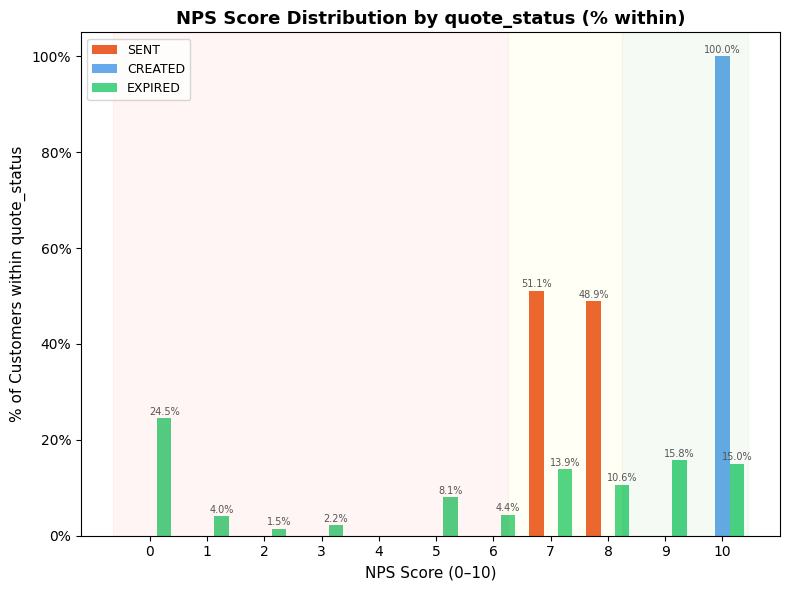

In [0]:
CHANNEL_COL = "quote_status"
NPS_COL     = "net_promoter_score"
CHANNELS    = ["SENT", "CREATED", "EXPIRED"]
COLORS      = {"SENT": "#E8450A", "CREATED": "#4C9BE8", "EXPIRED": "#2ECC71"}
print(master_df[CHANNEL_COL].value_counts())
plot_channel_nps(master_df)


## Renewal Feedback

### CSAT Score

### Premium Increase

In [0]:
master_df['premium_increase'] = master_df['policy_renewal_next_period_amt'] - master_df['policy_renewal_current_period_amt'] 
master_df.groupby('net_promoter_score')['premium_increase'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])


,count,mean,median,std,min,max
net_promoter_score,,,,,,
0.0,2908,92.168621,65.805,102.350005,-139.8900,583.6700
1.0,2938,90.514922,62.51,101.901573,-116.7000,589.4000
2.0,2461,89.245234,63.37,101.860968,-103.2200,599.4600
3.0,1268,84.634921,61.43,95.510051,-116.9100,552.2400
4.0,1174,87.782104,63.69,98.697331,-110.4900,571.2000
5.0,3818,94.822397,67.61,104.581907,-123.5900,583.9200
6.0,3778,93.638851,66.42,102.951273,-113.5100,574.1100
7.0,11136,88.284461,62.06,98.260237,-122.1600,595.9500
8.0,10753,93.050702,66.19,101.065297,-131.7800,606.0500


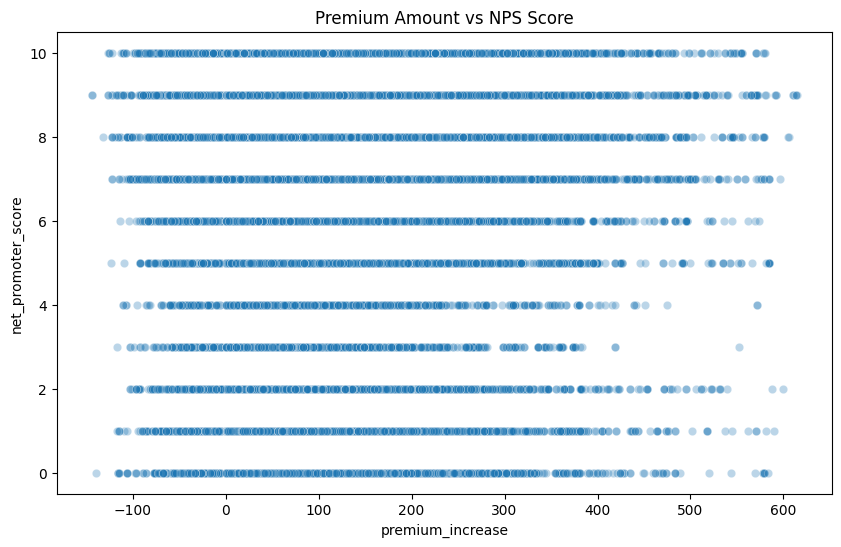

In [0]:
plt.figure(figsize=(10,6))
sns.scatterplot( data=master_df, x='premium_increase', y='net_promoter_score', alpha=0.3)
plt.title('Premium Amount vs NPS Score')
plt.show()

2908
2938
2461
1268
1174
3818
3778
11136
10753
10577
11289


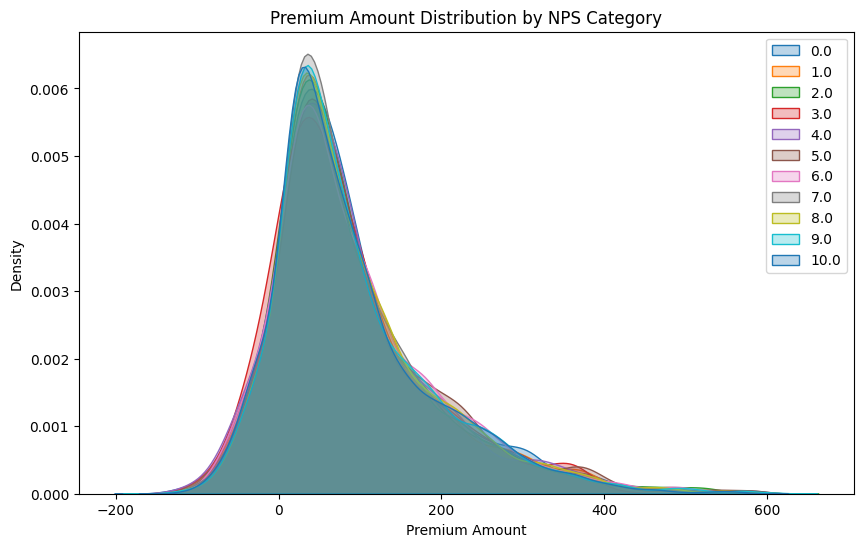

In [0]:
plt.figure(figsize=(10,6))
for cat in [0.0, 1.0,  2.0,  3.0, 4.0,  5.0,  6.0,  7.0,  8.0,  9.0,  10.0]:
    print(len(master_df[master_df['net_promoter_score'] == cat]))
    sns.kdeplot(
        data=master_df[master_df['net_promoter_score'] == cat],
        x='premium_increase',
        fill=True,
        alpha=0.3,
        label=cat
    )
 
plt.title('Premium Amount Distribution by NPS Category')
plt.xlabel('Premium Amount')
plt.ylabel('Density')
plt.legend()
plt.show()

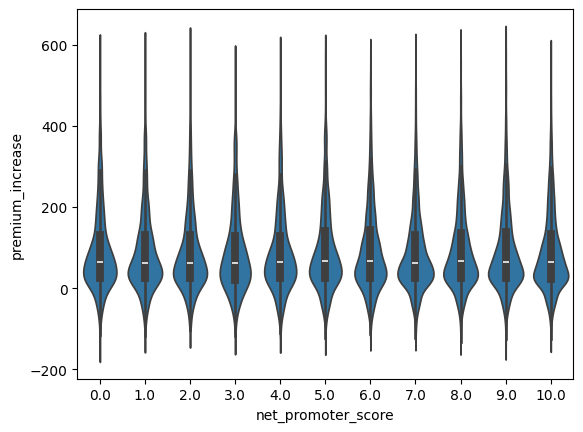

In [0]:
sns.violinplot(
    data=master_df,
    x='net_promoter_score',
    y='premium_increase'
)
plt.show()

### Digital Renewal


policy_sales_channel
ONLINE    20488
BRANCH     6856
AGENT      6718
Name: count, dtype: int64


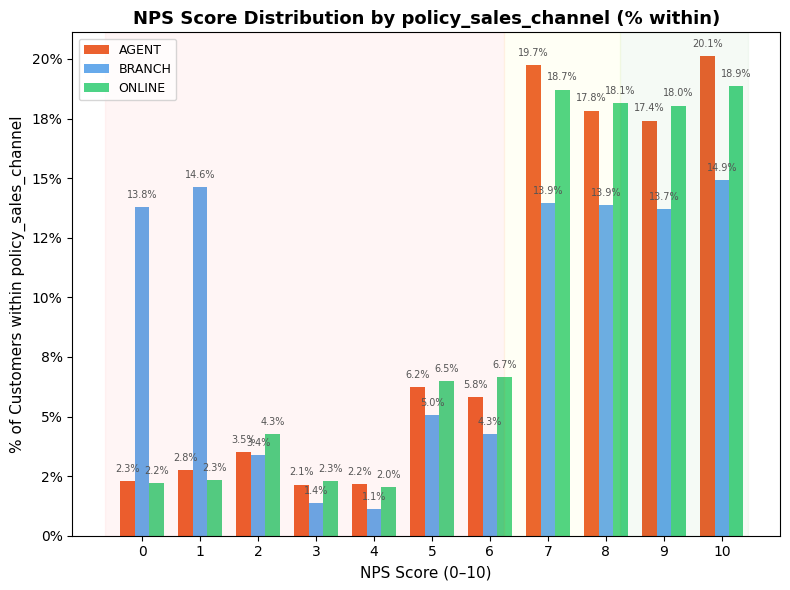

In [0]:
CHANNEL_COL = "policy_sales_channel"
NPS_COL     = "net_promoter_score"
CHANNELS    = ["AGENT", "BRANCH", "ONLINE"]
COLORS      = {"AGENT": "#E8450A", "BRANCH": "#4C9BE8", "ONLINE": "#2ECC71"}
master_df_1 = master_df[master_df['is_policy_renewal']=='Y'].copy()
print(master_df_1[CHANNEL_COL].value_counts())
plot_channel_nps(master_df_1)


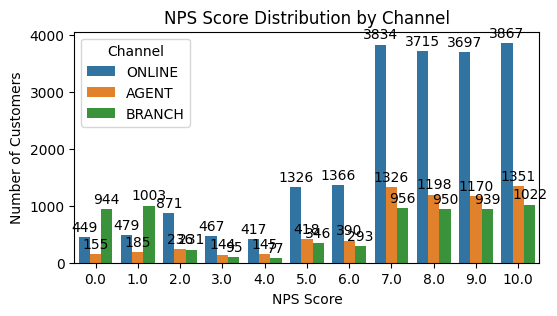

In [0]:
master_df_1 = master_df[master_df['is_policy_renewal']=='Y'].copy()
plt.figure(figsize=(6, 3))
ax= sns.countplot( data=master_df_1, x='net_promoter_score', hue='policy_sales_channel', legend='auto')
for container in ax.containers:
   ax.bar_label(container, fmt='%d', label_type='edge', padding=2)
plt.title('NPS Score Distribution by Channel')
plt.xlabel('NPS Score')
plt.ylabel('Number of Customers')
plt.legend(title='Channel') 
plt.show() 

In [0]:
master_df_1 = master_df[(master_df['is_policy_renewal']=='Y') & (master_df['policy_sales_channel'] == 'ONLINE')].copy()
analysis_df  = master_df_1.groupby(['net_promoter_score'])['customer_sk'].agg(['count']).reset_index()
analysis_df['prop'] = (analysis_df['count']/analysis_df['count'].sum() ) *100
print(master_df_1['net_promoter_score'].mean())
analysis_df

7.2538557


,net_promoter_score,count,prop
0,0.0,449,2.191527
1,1.0,479,2.337954
2,2.0,871,4.251269
3,3.0,467,2.279383
4,4.0,417,2.035338
5,5.0,1326,6.472081
6,6.0,1366,6.667317
7,7.0,3834,18.713393
8,8.0,3715,18.132565
9,9.0,3697,18.044709


### Number of Customer Contacts During Renewal


In [0]:
master_df.groupby('net_promoter_score')['customer_service_call_frequency'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])


,count,mean,median,std,min,max
net_promoter_score,,,,,,
0.0,1380,2.818116,3.0,1.940625,0.0,6.0
1.0,1306,2.663859,2.0,2.001041,0.0,6.0
2.0,1123,2.624221,2.0,1.929095,0.0,6.0
3.0,552,2.894928,3.0,1.926935,0.0,6.0
4.0,554,2.601083,2.0,1.873407,0.0,6.0
5.0,1736,2.760945,2.0,2.017187,0.0,6.0
6.0,1804,2.888027,3.0,2.048955,0.0,6.0
7.0,5247,2.636745,2.0,1.958181,0.0,6.0
8.0,5098,2.636328,2.0,1.946194,0.0,6.0


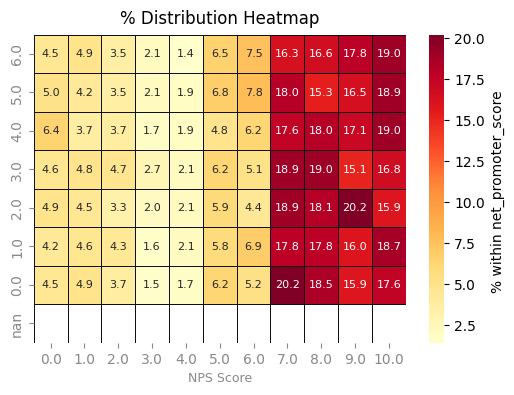

In [0]:
ct = master_df.groupby(['customer_service_call_frequency', 'net_promoter_score']).size().reset_index(name="count")
ct["pct_within_channel"] = ct.groupby('customer_service_call_frequency')["count"].transform(lambda x: x / x.sum() * 100).round(1)
fig, ax3 = plt.subplots(figsize=(6, 4))
pct_pivot = ct.pivot(index='net_promoter_score', columns='customer_service_call_frequency', values="pct_within_channel").fillna(0).reindex(columns=master_df['customer_service_call_frequency'].unique())
sns.heatmap(
    pct_pivot.T.sort_index(ascending=False),
    ax=ax3, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, linecolor="#0F1117",
    cbar_kws={f"label": "% within net_promoter_score "},
    annot_kws={"size": 8}
)
ax3.set_title("% Distribution Heatmap",fontsize=12, pad=8)
ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
ax3.set_ylabel("",          color="#888", fontsize=9)
ax3.tick_params(colors="#888")
plt.show()

### Renewal Feedback

### Renewal Escalation Flag

## Claims Feedback

### CSAT Score

In [0]:
master_df['claim_satisfaction_score'].value_counts()

claim_satisfaction_score
7.0     810
6.0     730
5.0     693
10.0    537
8.0     510
9.0     476
4.0     356
1.0     336
2.0     297
3.0     280
Name: count, dtype: int64

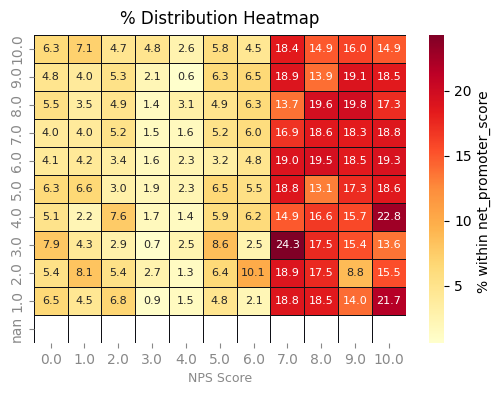

In [0]:
ct = master_df.groupby(['claim_satisfaction_score', 'net_promoter_score']).size().reset_index(name="count")
ct["pct_within_channel"] = ct.groupby('claim_satisfaction_score')["count"].transform(lambda x: x / x.sum() * 100).round(1)
fig, ax3 = plt.subplots(figsize=(6, 4))
pct_pivot = ct.pivot(index='net_promoter_score', columns='claim_satisfaction_score', values="pct_within_channel").fillna(0).reindex(columns=master_df['claim_satisfaction_score'].unique())
sns.heatmap(
    pct_pivot.T.sort_index(ascending=False),
    ax=ax3, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, linecolor="#0F1117",
    cbar_kws={f"label": "% within net_promoter_score "},
    annot_kws={"size": 8}
)
ax3.set_title("% Distribution Heatmap",fontsize=12, pad=8)
ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
ax3.set_ylabel("",          color="#888", fontsize=9)
ax3.tick_params(colors="#888")
plt.show()

### Claim Settlement TAT

In [0]:
master_df['claim_settlement_tat'] = (pd.to_datetime(master_df['claim_settlement_date']) - pd.to_datetime(master_df['claim_reported_date'])).dt.days
master_df.groupby('net_promoter_score')['claim_settlement_tat'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])

,count,mean,median,std,min,max
net_promoter_score,,,,,,
0.0,188,21.515957,0.0,33.896741,0.0,99.0
1.0,176,31.437500,0.0,37.150298,0.0,98.0
2.0,172,23.883721,0.0,33.919553,0.0,153.0
3.0,68,29.102941,0.0,35.495696,0.0,92.0
4.0,73,30.890411,0.0,35.807185,0.0,99.0
5.0,210,22.138095,0.0,32.010091,0.0,95.0
6.0,194,19.876289,0.0,33.860659,0.0,122.0
7.0,681,25.522761,0.0,35.994646,0.0,158.0
8.0,625,26.547200,0.0,34.978126,0.0,102.0


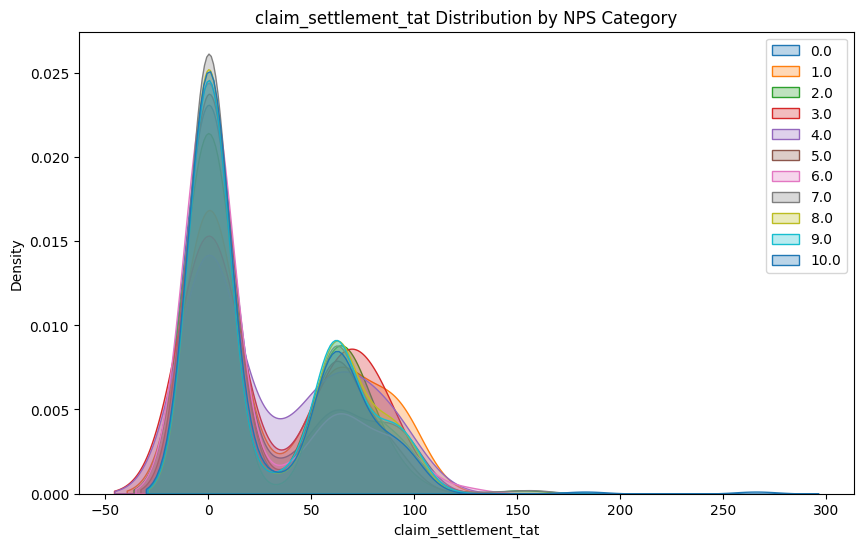

In [0]:
plt.figure(figsize=(10,6))
 
for cat in [0.0, 1.0,  2.0,  3.0, 4.0,  5.0,  6.0,  7.0,  8.0,  9.0,  10.0]:
    # print(len(master_df[master_df['net_promoter_score'] == cat]))
    sns.kdeplot(
        data=master_df[master_df['net_promoter_score'] == cat],
        x='claim_settlement_tat',
        fill=True,
        alpha=0.3,
        label=cat
    )
 
plt.title('claim_settlement_tat Distribution by NPS Category')
plt.xlabel('claim_settlement_tat')
plt.ylabel('Density')
plt.legend()
plt.show()

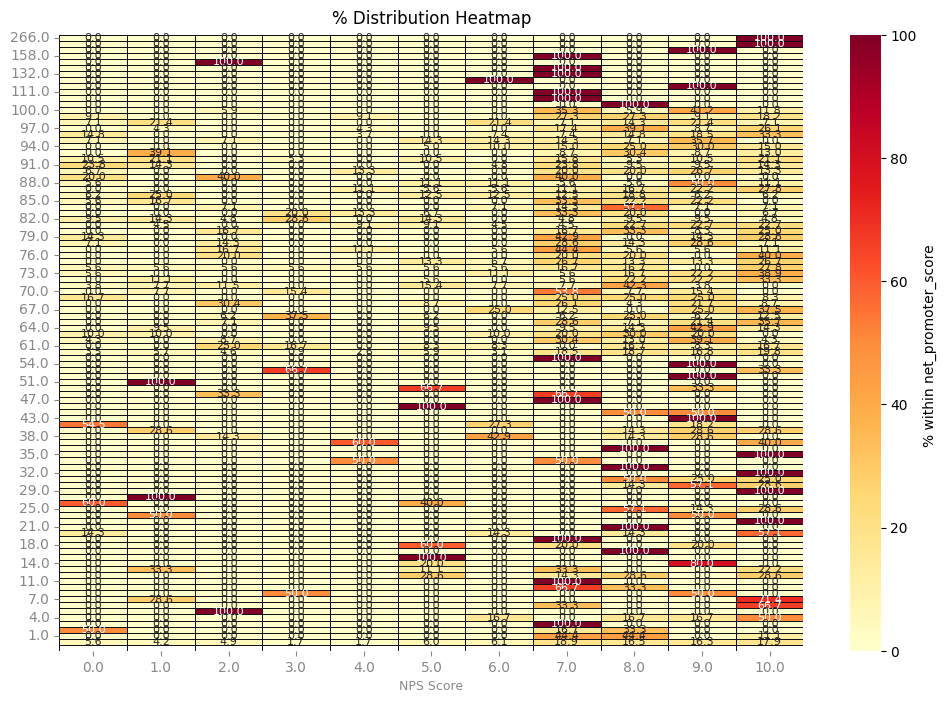

In [0]:
master_df['claim_settlement_tat'].value_counts()
pd.crosstab( master_df['claim_settlement_tat'], master_df['net_promoter_score']).round(1)

ct = master_df.groupby(['claim_settlement_tat', 'net_promoter_score']).size().reset_index(name="count")
ct["pct_within_channel"] = ct.groupby('claim_settlement_tat')["count"].transform(lambda x: x / x.sum() * 100).round(1)
fig, ax3 = plt.subplots(figsize=(12, 8))
pct_pivot = ct.pivot(index='net_promoter_score', columns='claim_settlement_tat', values="pct_within_channel").fillna(0).reindex(columns=master_df['claim_settlement_tat'].unique())
sns.heatmap(
    pct_pivot.T.sort_index(ascending=False),
    ax=ax3, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, linecolor="#0F1117",
    cbar_kws={f"label": "% within net_promoter_score "},
    annot_kws={"size": 8}
)
ax3.set_title("% Distribution Heatmap",fontsize=12, pad=8)
ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
ax3.set_ylabel("",          color="#888", fontsize=9)
ax3.tick_params(colors="#888")
plt.show()

### Claim Escalation Flag

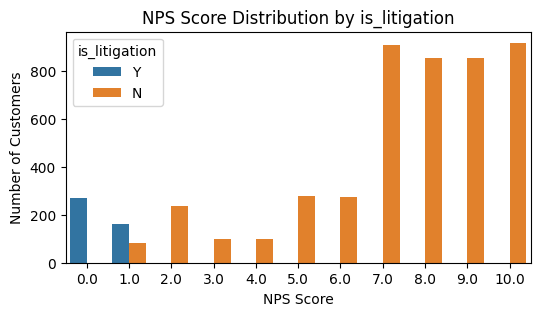

In [0]:
master_df_1 = master_df[master_df['claim_id']!=''].copy()
plt.figure(figsize=(6, 3))
sns.countplot( data=master_df_1, x='net_promoter_score', hue='is_litigation')
plt.title('NPS Score Distribution by is_litigation')
plt.xlabel('NPS Score')
plt.ylabel('Number of Customers')
plt.legend(title='is_litigation') 
plt.show() 

is_litigation
N    4595
Y     430
Name: count, dtype: int64


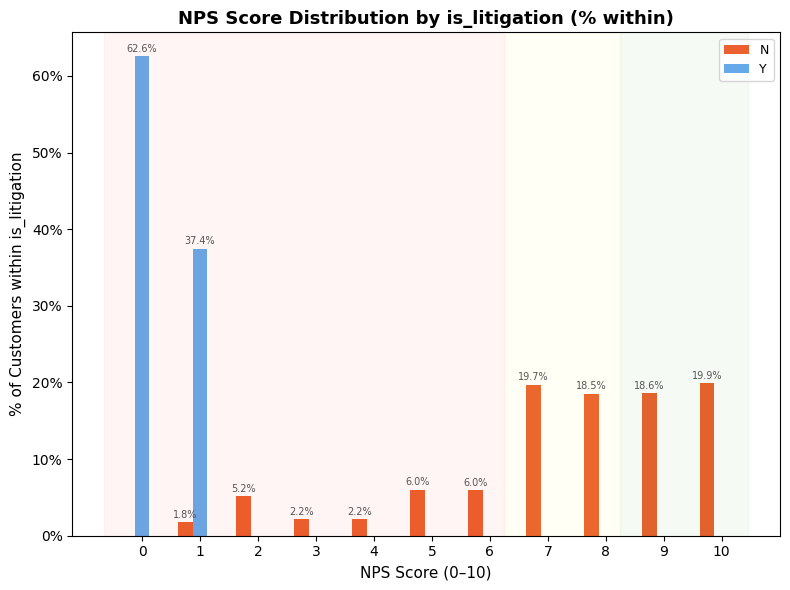

In [0]:
CHANNEL_COL = "is_litigation"
NPS_COL     = "net_promoter_score"
CHANNELS    = ["N", "Y"]
COLORS      = {"N": "#E8450A", "Y": "#4C9BE8"}
master_df_1 = master_df[master_df['claim_id']!=''].copy()
print(master_df_1[CHANNEL_COL].value_counts())
plot_channel_nps(master_df_1)


is_litigation  net_promoter_score  count  pct_within_channel
            N                 1.0     82                 1.8
            N                 2.0    237                 5.2
            N                 3.0     99                 2.2
            N                 4.0    100                 2.2
            N                 5.0    276                 6.0
            N                 6.0    275                 6.0
            N                 7.0    905                19.7
            N                 8.0    852                18.5
            N                 9.0    853                18.6
            N                10.0    916                19.9
            Y                 0.0    269                62.6
            Y                 1.0    161                37.4


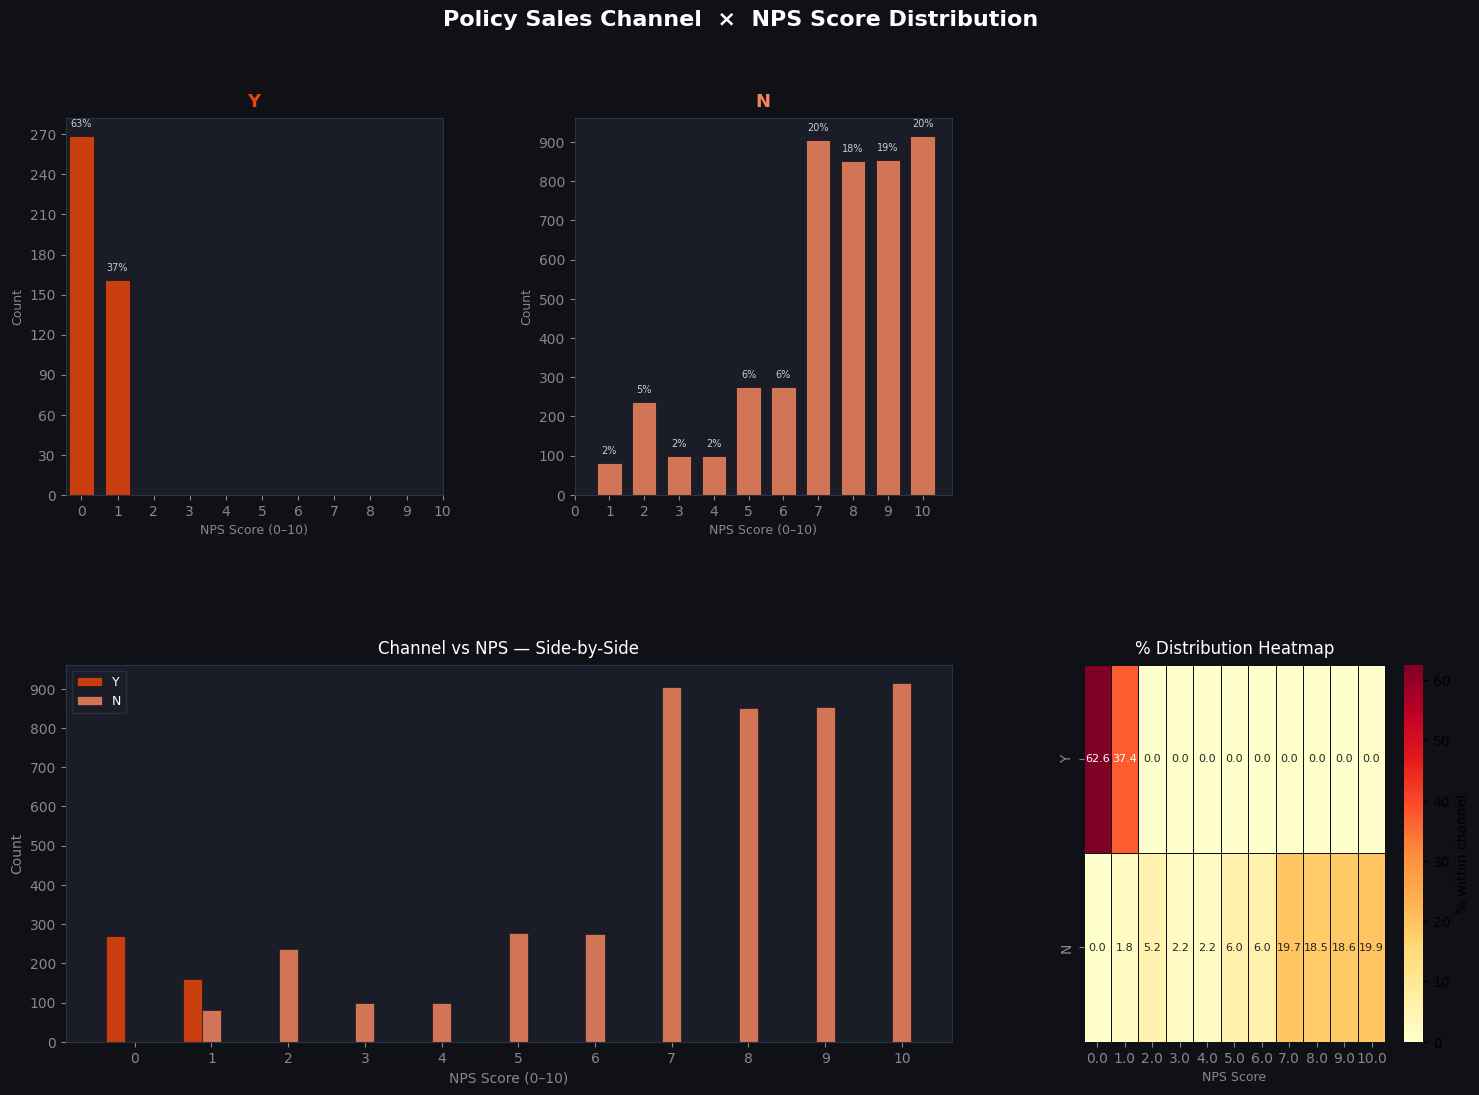

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import MaxNLocator
 
# ── Config ──────────────────────────────────────────────────────────────────
CHANNEL_COL = "is_litigation"
NPS_COL     = "net_promoter_score"          # change to your actual NPS column name
CHANNELS    = ['Y', 'N']
CHANNEL_COLORS = {
    "Y": "#E8450A",   # orange-red accent (matches your dashboard)
    "N" : "#F4845F",
    # "BRANCH": "#FAC7B3",
}
NPS_BINS = list(range(0, 11))      # 0–10
 
# ── 1. Count & % Table ───────────────────────────────────────────────────────
def channel_nps_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Returns count + row-% of each NPS score per channel."""
    ct = (
        df.groupby([CHANNEL_COL, NPS_COL])
          .size()
          .reset_index(name="count")
    )
    ct["pct_within_channel"] = (
        ct.groupby(CHANNEL_COL)["count"]
          .transform(lambda x: x / x.sum() * 100)
          .round(1)
    )
    return ct
 
# ── 2. Main Plot ─────────────────────────────────────────────────────────────
def plot_channel_nps1(df: pd.DataFrame):
    stats = channel_nps_stats(df)
    print(stats.to_string(index=False))          # console table
 
    fig = plt.figure(figsize=(18, 12))
    fig.patch.set_facecolor("#0F1117")
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
 
    # ── Row 0: Per-channel NPS distribution (count bars) ────────────────────
    for col_idx, channel in enumerate(CHANNELS):
        ax = fig.add_subplot(gs[0, col_idx])
        ax.set_facecolor("#1A1D27")
 
        sub = stats[stats[CHANNEL_COL] == channel].sort_values(NPS_COL)
        color = CHANNEL_COLORS[channel]
 
        bars = ax.bar(
            sub[NPS_COL], sub["count"],
            color=color, alpha=0.85, width=0.7,
            edgecolor="#0F1117", linewidth=0.6
        )
 
        # Annotate % on top of each bar
        for bar, pct in zip(bars, sub["pct_within_channel"]):
            if bar.get_height() > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(sub["count"]) * 0.02,
                    f"{pct:.0f}%", ha="center", va="bottom",
                    fontsize=7, color="#CCCCCC"
                )
 
        ax.set_title(channel, color=color, fontsize=13, fontweight="bold", pad=8)
        ax.set_xlabel("NPS Score (0–10)", color="#888", fontsize=9)
        ax.set_ylabel("Count",           color="#888", fontsize=9)
        ax.set_xticks(NPS_BINS)
        ax.tick_params(colors="#888")
        for spine in ax.spines.values():
            spine.set_edgecolor("#2E3244")
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
 
    # ── Row 1 left-center: Grouped bar – all channels side-by-side ──────────
    ax2 = fig.add_subplot(gs[1, :2])
    ax2.set_facecolor("#1A1D27")
 
    pivot = stats.pivot(index=NPS_COL, columns=CHANNEL_COL, values="count").fillna(0)
    pivot = pivot.reindex(columns=CHANNELS)   # consistent order
    x      = np.arange(len(NPS_BINS))
    w      = 0.25
 
    for i, channel in enumerate(CHANNELS):
        if channel in pivot.columns:
            ax2.bar(
                x + i * w, pivot[channel],
                width=w, label=channel,
                color=CHANNEL_COLORS[channel], alpha=0.85,
                edgecolor="#0F1117", linewidth=0.5
            )
 
    ax2.set_xticks(x + w)
    ax2.set_xticklabels(NPS_BINS)
    ax2.set_xlabel("NPS Score (0–10)", color="#888", fontsize=10)
    ax2.set_ylabel("Count",           color="#888", fontsize=10)
    ax2.set_title("Channel vs NPS — Side-by-Side", color="white", fontsize=12, pad=8)
    ax2.legend(facecolor="#1A1D27", edgecolor="#2E3244", labelcolor="white", fontsize=9)
    ax2.tick_params(colors="#888")
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    for spine in ax2.spines.values():
        spine.set_edgecolor("#2E3244")
 
    # ── Row 1 right: Stacked % heatmap ──────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 2])
    ax3.set_facecolor("#1A1D27")
 
    pct_pivot = stats.pivot(
        index=NPS_COL, columns=CHANNEL_COL, values="pct_within_channel"
    ).fillna(0).reindex(columns=CHANNELS)
 
    sns.heatmap(
        pct_pivot.T,
        ax=ax3, annot=True, fmt=".1f", cmap="YlOrRd",
        linewidths=0.4, linecolor="#0F1117",
        cbar_kws={"label": "% within channel"},
        annot_kws={"size": 8}
    )
    ax3.set_title("% Distribution Heatmap", color="white", fontsize=12, pad=8)
    ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
    ax3.set_ylabel("",          color="#888", fontsize=9)
    ax3.tick_params(colors="#888")
 
    fig.suptitle(
        "Policy Sales Channel  ×  NPS Score Distribution",
        color="white", fontsize=16, fontweight="bold", y=0.97
    )
 
    plt.savefig("channel_nps_distribution.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    return stats
 
 
# ── Quick demo with synthetic data (replace with your real df) ───────────────
if __name__ == "__main__":
    rng = np.random.default_rng(42)
    n   = 5000
 
    # # Skew NPS differently per channel to make it interesting
    # nps_map = {
    #     "ONLINE": rng.choice(range(11), n // 3, p=[.02,.02,.03,.04,.06,.08,.10,.13,.17,.18,.17]),
    #     "AGENT" : rng.choice(range(11), n // 3, p=[.05,.05,.07,.08,.09,.10,.12,.13,.13,.10,.08]),
    #     "BRANCH": rng.choice(range(11), n // 3, p=[.08,.07,.08,.08,.09,.10,.11,.12,.11,.09,.07]),
    # }
    # rows = []
    # for ch, scores in nps_map.items():
    #     for s in scores:
    #         rows.append({CHANNEL_COL: ch, NPS_COL: s})
 
    # df = pd.DataFrame(rows)
    stats_df = plot_channel_nps1(master_df[master_df['claim_id']!=''].copy()
)

### Claim Complaint Flag

In [0]:
fact_complaint['complaint_driver'].value_counts()

complaint_driver
Staff Conduct       209
System Error        158
Service Issue       151
Delay               150
Product Feature     131
Miscommunication    129
Name: count, dtype: int64

In [0]:
master_df_1 = master_df[master_df['claim_id']!=''].copy()
# Count complaints per customer
complaints_per_customer = (
    master_df_1
    .groupby('customer_sk')
    .agg(
        complaint_count=('complaint_id', 'nunique'),
        avg_nps=('net_promoter_score', 'mean')
    )
    .reset_index()
)

# Average NPS for each complaint count
nps_by_complaints = (
    complaints_per_customer
    .groupby('complaint_count')
    .agg(
        customers=('customer_sk', 'nunique'),
        avg_nps=('avg_nps', 'mean')
    )
    .reset_index()
    .sort_values('complaint_count')
)

print(nps_by_complaints)

   complaint_count  customers   avg_nps
0                0      26066  6.949359
1                1        687  3.940320
2                2         95  8.484211
3                3         17  8.529411


In [0]:
master_df[master_df['complaint_id']=="CMP00039_0000429"]

,customer_sk,policy_sk,claim_sk,person_sk,account_sk,channel_sk,marketing_sk,date_sk,override_sk,person_id,policy_renewal_current_period_amt,policy_renewal_next_period_amt,net_promoter_score,net_promotor_code_segment,customer_satisfaction,policy_start_ts,policy_issue_date,policy_sales_channel,policy_status,is_policy_renewal,policy_cycle,claim_id,claim_status,claim_channel,is_litigation,claim_reported_date,claim_satisfaction_score,claim_settlement_date,is_operational_paperless_consent,account_id,account_creation_type,account_last_access_ts,override_reason,customer_service_call_frequency,quote_id,quote_status,quote_date,complaint_date,complaint_id,complaint_resolved_date,is_financial_ombudsman_service_referral,complaint_status,complaint_upheld_status,policy_issuance_tat,premium_increase,claim_settlement_tat,account_dormancy_days,digital_engagement_score,complaint_tat
28979,5105,15476,-1,130644,5105,1,20054,20230302,-1,PER_20260615_181205_42_131235,1174.9600,1175.3900,3.0,DETRACTORS,VERY_SATISFIED,2023-03-16 10:52:12,2023-03-02,ONLINE,ACTIVE,N,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005105,BRANCH,2025-03-09 00:00:00,NaN,5.0,QUO_20260615_181205_42_030932,ACCEPTED,2021-09-02,2025-03-25,CMP00039_0000429,2025-03-27,N,Closed,Partially Upheld,14,0.4300,NaN,465,0,2.0
28980,5105,15476,-1,130644,5105,1,20054,20230302,-1,PER_20260615_181205_42_131235,1174.9600,1175.3900,3.0,DETRACTORS,VERY_SATISFIED,2023-03-16 10:52:12,2023-03-02,ONLINE,ACTIVE,N,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005105,BRANCH,2025-03-09 00:00:00,NaN,5.0,QUO_20260615_181205_42_030933,ACCEPTED,2023-11-02,2025-03-25,CMP00039_0000429,2025-03-27,N,Closed,Partially Upheld,14,0.4300,NaN,465,0,2.0
28981,5105,15476,-1,130644,5105,1,20054,20230302,-1,PER_20260615_181205_42_131235,1174.9600,1175.3900,3.0,DETRACTORS,VERY_SATISFIED,2023-03-16 10:52:12,2023-03-02,ONLINE,ACTIVE,N,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005105,BRANCH,2025-03-09 00:00:00,NaN,5.0,QUO_20260615_181205_42_030931,ACCEPTED,2021-12-08,2025-03-25,CMP00039_0000429,2025-03-27,N,Closed,Partially Upheld,14,0.4300,NaN,465,0,2.0
28982,5105,15476,-1,130644,5105,1,20054,20230302,-1,PER_20260615_181205_42_131235,1174.9600,1175.3900,3.0,DETRACTORS,VERY_SATISFIED,2023-03-16 10:52:12,2023-03-02,ONLINE,ACTIVE,N,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005105,BRANCH,2025-03-09 00:00:00,NaN,5.0,QUO_20260615_181205_42_030932,ACCEPTED,2021-09-02,2025-03-25,CMP00039_0000429,2025-03-27,N,Closed,Partially Upheld,14,0.4300,NaN,465,0,2.0
29029,5105,15568,-1,130644,5105,1,20054,20230212,-1,PER_20260615_181205_42_131235,391.1700,513.7300,3.0,DETRACTORS,VERY_SATISFIED,2023-02-12 10:52:12,2023-02-12,ONLINE,ACTIVE,Y,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005105,BRANCH,2025-03-09 00:00:00,NaN,5.0,QUO_20260615_181205_42_030932,ACCEPTED,2021-09-02,2025-03-25,CMP00039_0000429,2025-03-27,N,Closed,Partially Upheld,0,122.5600,NaN,465,0,2.0
29030,5105,15568,-1,130644,5105,1,20054,20230212,-1,PER_20260615_181205_42_131235,391.1700,513.7300,3.0,DETRACTORS,VERY_SATISFIED,2023-02-12 10:52:12,2023-02-12,ONLINE,ACTIVE,Y,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005105,BRANCH,2025-03-09 00:00:00,NaN,5.0,QUO_20260615_181205_42_030933,ACCEPTED,2023-11-02,2025-03-25,CMP00039_0000429,2025-03-27,N,Closed,Partially Upheld,0,122.5600,NaN,465,0,2.0
29031,5105,15568,-1,130644,5105,1,20054,20230212,-1,PER_20260615_181205_42_131235,391.1700,513.7300,3.0,DETRACTORS,VERY_SATISFIED,2023-02-12 10:52:12,2023-02-12,ONLINE,ACTIVE,Y,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005105,BRANCH,2025-03-09 00:00:00,NaN,5.0,QUO_20260615_181205_42_030931,ACCEPTED,2021-12-08,2025-03-25,CMP00039_0000429,2025-03-27,N,Closed,Partially Upheld,0,122.5600,NaN,465,0,2.0
29032,5105,15568,-1,130644,5105,1,20054,20230212,-1,PER_20260615_181205_42_131235,391.1700,513.7300,3.0,DETRACTORS,VERY_SATISFIED,2023-02-12 10:52:12,2023-02-12,ONLINE,ACTIVE,Y,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_2026061

### Claims Feedback

### Claim Channel Used

In [0]:
master_df['claim_channel'].value_counts()

claim_channel
ONLINE    2780
AGENT     1186
BRANCH    1059
Name: count, dtype: int64

In [0]:
master_df['claim_channel'].unique()

array([nan, 'AGENT', 'BRANCH', 'ONLINE'], dtype=object)

claim_channel
ONLINE    2780
AGENT     1186
BRANCH    1059
Name: count, dtype: int64


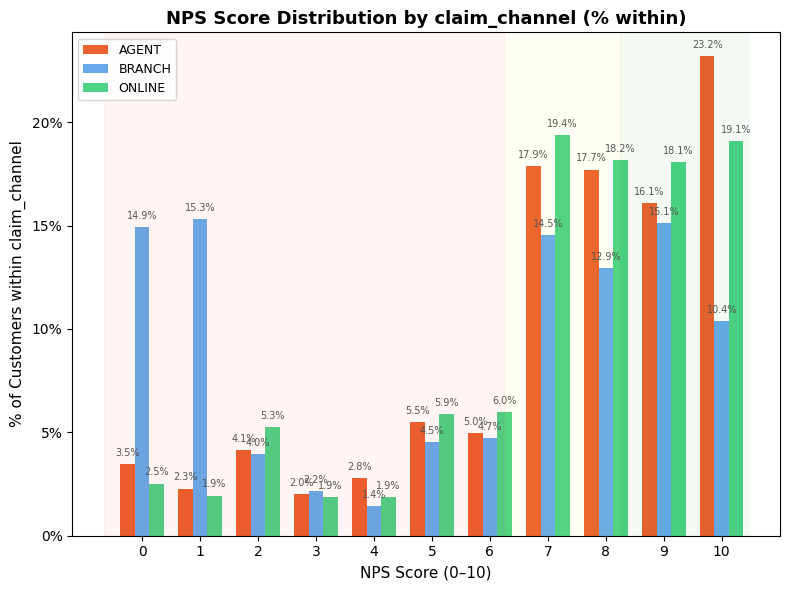

In [0]:
CHANNEL_COL = "claim_channel"
NPS_COL     = "net_promoter_score"
CHANNELS    = ["AGENT", "BRANCH", "ONLINE"]
COLORS      = {"AGENT": "#E8450A", "BRANCH": "#4C9BE8", "ONLINE": "#2ECC71"}
print(master_df_1[CHANNEL_COL].value_counts())
plot_channel_nps(master_df_1)


## Support Feedback

### CSAT Score

In [0]:
master_df['customer_satisfaction'].value_counts()

customer_satisfaction
SATISFIED         21154
NEUTRAL           15672
DISSATISFIED      13435
VERY_SATISFIED    11839
Name: count, dtype: int64

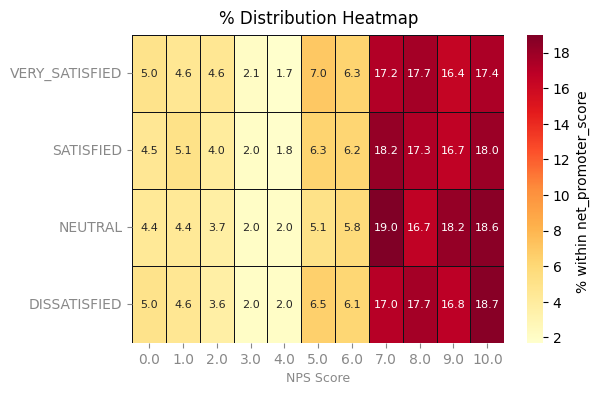

In [0]:
ct = master_df.groupby(['customer_satisfaction', 'net_promoter_score']).size().reset_index(name="count")
ct["pct_within_channel"] = ct.groupby('customer_satisfaction')["count"].transform(lambda x: x / x.sum() * 100).round(1)
fig, ax3 = plt.subplots(figsize=(6, 4))
pct_pivot = ct.pivot(index='net_promoter_score', columns='customer_satisfaction', values="pct_within_channel").fillna(0).reindex(columns=master_df['customer_satisfaction'].unique())
sns.heatmap(
    pct_pivot.T.sort_index(ascending=False),
    ax=ax3, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, linecolor="#0F1117",
    cbar_kws={f"label": "% within net_promoter_score "},
    annot_kws={"size": 8}
)
ax3.set_title("% Distribution Heatmap",fontsize=12, pad=8)
ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
ax3.set_ylabel("",          color="#888", fontsize=9)
ax3.tick_params(colors="#888")
plt.show()

### First Contact Resolution (FCR)

### SLA Breach

### Self-Service Adoption

In [0]:
master_df.shape

(62100, 46)

In [0]:
master_df["account_dormancy_days"] = (((pd.Timestamp.today().normalize() - pd.to_datetime(master_df["account_last_access_ts"]))).dt.total_seconds() // 86400).astype(int)
master_df["digital_engagement_score"] = (
    (master_df["account_creation_type"] == "Online") & 
 (master_df["is_operational_paperless_consent"] == "Y") & 
 (master_df["account_dormancy_days"] < 30)
).astype(int)

master_df["digital_engagement_score"].value_counts()

digital_engagement_score
0    62100
Name: count, dtype: int64

In [0]:
master_df.shape

(62100, 48)

### Resolution Turnaround Time

In [0]:
master_df['complaint_tat'] = (pd.to_datetime(master_df['complaint_resolved_date']) - pd.to_datetime(master_df['complaint_date'])).dt.days
master_df['complaint_tat'].value_counts()

complaint_tat
0.0     453
1.0     433
2.0     418
5.0     142
6.0     126
7.0     116
4.0     112
3.0     108
19.0     21
20.0     20
27.0     17
8.0      14
15.0     14
12.0     13
22.0     12
17.0     11
10.0     11
29.0     10
18.0      9
13.0      9
30.0      8
14.0      8
21.0      8
16.0      8
26.0      7
28.0      7
24.0      7
11.0      7
25.0      6
9.0       5
23.0      4
Name: count, dtype: int64

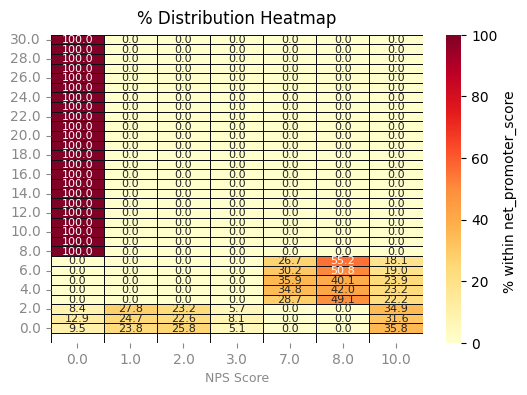

In [0]:
ct = master_df.groupby(['complaint_tat', 'net_promoter_score']).size().reset_index(name="count")
ct["pct_within_channel"] = ct.groupby('complaint_tat')["count"].transform(lambda x: x / x.sum() * 100).round(1)
fig, ax3 = plt.subplots(figsize=(6, 4))
pct_pivot = ct.pivot(index='net_promoter_score', columns='complaint_tat', values="pct_within_channel").fillna(0).reindex(columns=master_df['complaint_tat'].unique())
sns.heatmap(
    pct_pivot.T.sort_index(ascending=False),
    ax=ax3, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.4, linecolor="#0F1117",
    cbar_kws={f"label": "% within net_promoter_score "},
    annot_kws={"size": 8}
)
ax3.set_title("% Distribution Heatmap",fontsize=12, pad=8)
ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
ax3.set_ylabel("",          color="#888", fontsize=9)
ax3.tick_params(colors="#888")
plt.show()

## Complaint Feedback

### CSAT Score

### Complaint Escalation Flag

Whether a complaint was escalated to a regulator (Financial Ombudsman Service) or senior management	FOS referral = extreme dissatisfaction; these customers have NPS 0-2 and are near-certain churners	NA	allianz_coe.gold.fact_complaint: is_financial_ombudsman_service_referral	fact_complaint : is_financial_ombudsman_service_referral	CASE WHEN is_financial_ombudsman_service_referral = 'Y' THEN 1 ELSE 0 END	Binary; expect <3% FOS referrals	Fact_Complaint : is_financial_ombudsman_service_referral


In [0]:
master_df.head()

,customer_sk,policy_sk,claim_sk,person_sk,account_sk,channel_sk,marketing_sk,date_sk,override_sk,person_id,policy_renewal_current_period_amt,policy_renewal_next_period_amt,net_promoter_score,net_promotor_code_segment,customer_satisfaction,policy_start_ts,policy_issue_date,policy_sales_channel,policy_status,is_policy_renewal,policy_cycle,claim_id,claim_status,claim_channel,is_litigation,claim_reported_date,claim_satisfaction_score,claim_settlement_date,is_operational_paperless_consent,account_id,account_creation_type,account_last_access_ts,override_reason,customer_service_call_frequency,quote_id,quote_status,quote_date,complaint_date,complaint_id,complaint_resolved_date,is_financial_ombudsman_service_referral,complaint_status,complaint_upheld_status,policy_issuance_tat,premium_increase,claim_settlement_tat,account_dormancy_days,digital_engagement_score,complaint_tat
0,25138,4,-1,64928,25138,2,12,20211103,-1,PER_20260615_181205_42_064420,1396.8400,1615.9900,8.0,PASSIVE,NEUTRAL,2021-11-06 15:11:43,2021-11-03,AGENT,ACTIVE,Y,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_025138,ONLINE,2025-05-30 00:00:00,NaN,1.0,QUO_20260615_181205_42_000017,ACCEPTED,2024-06-29,2024-09-22,CMP00325_0000715,2024-09-28,N,Closed,Not Upheld,3,219.1500,NaN,383,0,6.0
1,5320,9,-1,63552,5320,1,16,20250423,-1,PER_20260615_181205_42_065035,364.9500,401.3100,0.0,DETRACTORS,NEUTRAL,2025-04-24 08:31:01,2025-04-23,ONLINE,ACTIVE,Y,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_005320,BRANCH,2025-02-02 00:00:00,NaN,1.0,QUO_20260615_181205_42_000023,ACCEPTED,2022-06-07,NaN,NaN,NaN,NaN,NaN,NaN,1,36.3600,NaN,500,0,NaN
2,20757,34,-1,140121,20757,2,48,20210806,-1,PER_20260615_181205_42_144179,1670.3600,1711.5500,8.0,PASSIVE,SATISFIED,2021-08-06 22:08:19,2021-08-06,AGENT,LAPSED,N,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_020757,ONLINE,2025-05-31 00:00:00,NaN,3.0,QUO_20260615_181205_42_000062,ACCEPTED,2024-10-17,2025-11-02,CMP00334_0000724,2025-11-09,N,Closed,Upheld,0,41.1900,NaN,382,0,7.0
3,20757,37,-1,140121,20757,1,48,20210802,-1,PER_20260615_181205_42_144179,374.6000,408.9800,8.0,PASSIVE,SATISFIED,2021-08-03 22:08:19,2021-08-02,ONLINE,ACTIVE,Y,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_020757,ONLINE,2025-05-31 00:00:00,NaN,3.0,QUO_20260615_181205_42_000063,ACCEPTED,2024-04-06,2025-05-13,CMP00335_0000725,2025-05-19,N,Closed,Partially Upheld,1,34.3800,NaN,382,0,6.0
4,20757,37,-1,140121,20757,1,48,20210802,-1,PER_20260615_181205_42_144179,374.6000,408.9800,8.0,PASSIVE,SATISFIED,2021-08-03 22:08:19,2021-08-02,ONLINE,ACTIVE,Y,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,ACC_20260615_181205_42_020757,ONLINE,2025-05-31 00:00:00,NaN,3.0,QUO_20260615_181205_42_000063,ACCEPTED,2024-04-06,2025-08-25,CMP00336_0000726,2025-08-30,N,Closed,Partially Upheld,1,34.3800,NaN,382,0,5.0


In [0]:
fact_complaint['is_financial_ombudsman_service_referral'].value_counts()

is_financial_ombudsman_service_referral
N    838
Y     90
Name: count, dtype: int64

In [0]:
master_df['is_financial_ombudsman_service_referral'].value_counts()

is_financial_ombudsman_service_referral
N    1953
Y     191
Name: count, dtype: int64

is_financial_ombudsman_service_referral
N    1953
Y     191
Name: count, dtype: int64


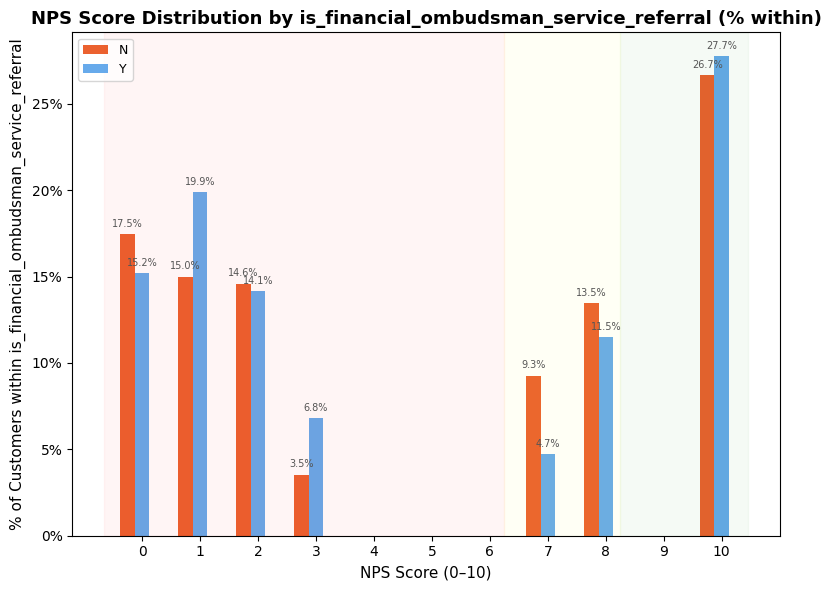

In [0]:
CHANNEL_COL = "is_financial_ombudsman_service_referral"
NPS_COL     = "net_promoter_score"
CHANNELS    = ["N", "Y"]
COLORS      = {"N": "#E8450A", "Y": "#4C9BE8"}

# complain flag?
# master_df_1 = master_df[master_df['claim_id']!=''].copy()
print(master_df[CHANNEL_COL].value_counts())
plot_channel_nps(master_df)


### Complaint Status Outcome

In [0]:
fact_complaint[['complaint_status', 'complaint_upheld_status']].value_counts()


complaint_status  complaint_upheld_status
Closed            Upheld                     342
                  Partially Upheld           298
                  Not Upheld                 288
Name: count, dtype: int64

In [0]:
master_df1 = master_df[master_df['complaint_status'].isin(['Resolved', 'Closed'])].copy()
master_df1[['complaint_upheld_status']].value_counts()

complaint_upheld_status
Upheld                     819
Partially Upheld           666
Not Upheld                 659
Name: count, dtype: int64

complaint_upheld_status
Upheld              819
Partially Upheld    666
Not Upheld          659
Name: count, dtype: int64


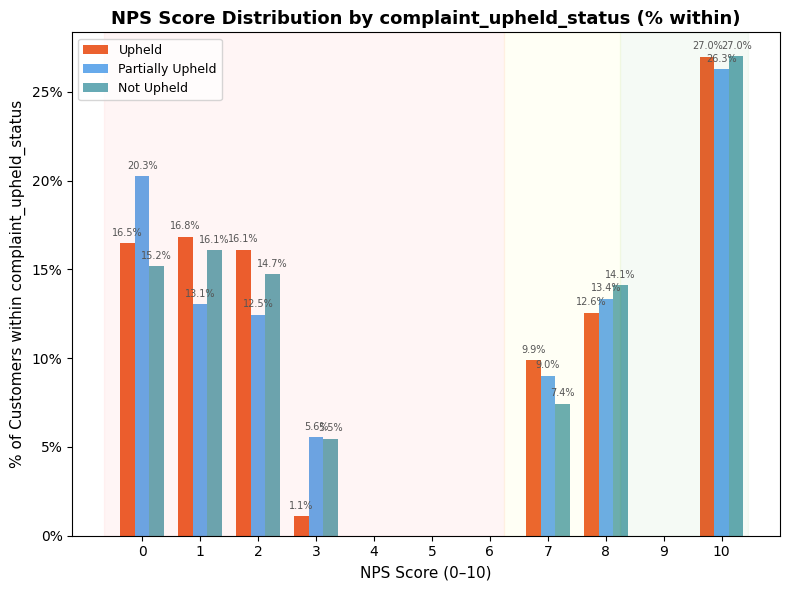

In [0]:
CHANNEL_COL = "complaint_upheld_status"
NPS_COL     = "net_promoter_score"
CHANNELS    = ["Upheld", "Partially Upheld", "Not Upheld"]
COLORS      = {"Upheld": "#E8450A", "Partially Upheld": "#4C9BE8", "Not Upheld": "#4C9BA8"}

# complain flag?
# master_df_1 = master_df[master_df['claim_id']!=''].copy()
print(master_df1[CHANNEL_COL].value_counts())
plot_channel_nps(master_df1)


### Repeat Complaint Flag

In [0]:
# Count complaints per customer and NPS score
complaints_per_customer = (
    master_df
    .groupby(['customer_sk', 'net_promoter_score'])['complaint_id']
    .nunique()
    .reset_index(name='complaint_count')
)

print(complaints_per_customer.head())

distribution_nps = (
    complaints_per_customer
    .groupby(['net_promoter_score', 'complaint_count'])
    .size()
    .reset_index(name='num_customers')
    .sort_values(['net_promoter_score', 'complaint_count'])
)
distribution_nps['pct_within_nps'] = (
    distribution_nps.groupby('net_promoter_score')['num_customers']
    .transform(lambda x: round(100 * x / x.sum(), 2))
)
complaints_per_customer['repeat_complaint_flag'] = (
    complaints_per_customer['complaint_count'] > 1
).astype(int)

repeat_by_nps = (
    complaints_per_customer
    .groupby('net_promoter_score')['repeat_complaint_flag']
    .agg(
        customers='count',
        repeat_customers='sum'
    )
    .reset_index()
)

repeat_by_nps['repeat_pct'] = round(
    100 * repeat_by_nps['repeat_customers'] / repeat_by_nps['customers'],
    2
)

print(repeat_by_nps.sort_values('net_promoter_score'))
print(distribution_nps)
print(distribution_nps)

   customer_sk  net_promoter_score  complaint_count
0            1                 0.0                0
1            2                 2.0                0
2            3                 5.0                0
3            4                 0.0                0
4            5                 3.0                0
    net_promoter_score  customers  repeat_customers  repeat_pct
0                  0.0       1355                 3        0.22
1                  1.0       1342                 3        0.22
2                  2.0       1073                 2        0.19
3                  3.0        539                 0        0.00
4                  4.0        534                 0        0.00
5                  5.0       1604                 0        0.00
6                  6.0       1612                 0        0.00
7                  7.0       4828                16        0.33
8                  8.0       4571                24        0.53
9                  9.0       4567               

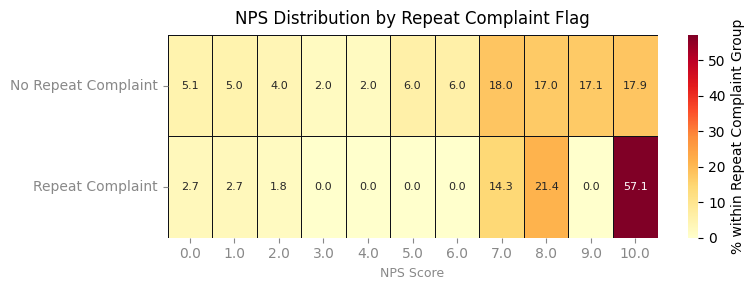

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Count complaints per customer and NPS
complaints_per_customer = (
    master_df
    .groupby(['customer_sk', 'net_promoter_score'])['complaint_id']
    .nunique()
    .reset_index(name='complaint_count')
)

# Create Repeat Complaint Flag
complaints_per_customer['repeat_complaint_flag'] = (
    complaints_per_customer['complaint_count'] > 1
).astype(int)

# Distribution table
ct = (
    complaints_per_customer
    .groupby(['repeat_complaint_flag', 'net_promoter_score'])
    .size()
    .reset_index(name='count')
)

# % within repeat complaint flag
ct["pct_within_flag"] = (
    ct.groupby('repeat_complaint_flag')["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
)

# Heatmap
fig, ax3 = plt.subplots(figsize=(8, 3))

pct_pivot = (
    ct.pivot(
        index='net_promoter_score',
        columns='repeat_complaint_flag',
        values='pct_within_flag'
    )
    .fillna(0)
)

# Rename for readability
pct_pivot.columns = [
    'No Repeat Complaint' if c == 0 else 'Repeat Complaint'
    for c in pct_pivot.columns
]

sns.heatmap(
    pct_pivot.T,
    ax=ax3,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#0F1117",
    cbar_kws={"label": "% within Repeat Complaint Group"},
    annot_kws={"size": 8}
)

ax3.set_title(
    "NPS Distribution by Repeat Complaint Flag",
    fontsize=12,
    pad=8
)
ax3.set_xlabel("NPS Score", color="#888", fontsize=9)
ax3.set_ylabel("", color="#888", fontsize=9)
ax3.tick_params(colors="#888")

plt.tight_layout()
plt.show()

### ComplaintFeedback